In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
data = pd.read_csv(r"C:\Users\Ivan Tan\Downloads\property_insurance_historical_data.csv")

print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")

# Print first few rows
print("\n First 5 rows:")
print(data.head())

# Print summary statistics (numeric columns only)
print("\n Summary statistics:")
print(data.describe())

# Print column names and data types
print("\n Column types:")
print(data.dtypes)

Dataset shape: 63189 rows, 38 columns

 First 5 rows:
      earned_exposure       policy_id underwriting_year policy_type  \
0  0.9252155845351104  TRNPOL000000R1              2021  homeownner   
1  0.9819822278201685  TRNPOL000001R2              2022  homeownner   
2  0.8151977797193338  TRNPOL000002R3              2019  homeownner   
3  0.9808944570661171  TRNPOL000003R4              2020  homeownner   
4  0.9177086469447747  TRNPOL000004R5              2023  homeownner   

  coverage_limit policy_duration recent_claim_activity underwriting_score  \
0       443800.0               4                     Y               92.0   
1       134400.0               2                     Y               79.0   
2       115000.0               3                     Y               99.0   
3       314100.0               1                     Y               94.0   
4       486700.0               5                     Y               87.0   

  has_deductible property_type  ...  is_lightning_prone_

C:\Users\Ivan Tan\AppData\Local\Temp\ipykernel_39504\3600580886.py:2: DtypeWarning: Columns (0,2,4,5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\Ivan Tan\Downloads\property_insurance_historical_data.csv")


In [5]:
# Handle Missing Value
bad_indices = ["-1", 9999, -20, "polystyrene"]  # remove the bad rows
data = data[~data.isin(bad_indices).any(axis=1)]

# Replace 999999 in 'prev_inspect_ago' with 0
data.loc[data['prev_inspect_ago'] == 999999, 'prev_inspect_ago'] = 0

# Where 'has_inspect' is 'N', set 'prev_inspect_ago' to 0
data.loc[data['has_inspect'].astype(str).str.upper().str.strip() == 'N', 'prev_inspect_ago'] = 0 # Replace 999999 in 'prev_inspect_ago' with 0
data.loc[data['prev_inspect_ago'] == 999999, 'prev_inspect_ago'] =0

# Where 'has_inspect' is 'N', set 'prev_inspect_ago' to 0
data.loc[data['has_inspect'].astype(str).str.upper().str.strip() == 'N', 'prev_inspect_ago'] = 0

In [6]:
# Define target variable
y = data['total_loss_value']

# Define features (remove non-predictive columns)
X = data.drop(columns=['total_loss_value', 'theft_loss_value', 'policy_id'])

In [9]:
# Step 1: Define binary Y/N columns
binary_yn_cols = [
    'recent_claim_activity',
    'has_deductible',
    'has_sprinkler',
    'has_fire_hydrant',
    'has_fire_extinguishers',
    'has_smoke_alarm',
    'has_inspect',
    'last_inspection_result',
    'has_guard_house',
    'has_hazardeous_items',
    'has_attended_ge_risk_prevention_course',
    'has_fire_dept_nearby',
    'local_fire_incident_rate',
    'is_lightning_prone_area',
    'high_density_area',
    'with_mortgage'
]

# Convert Y/N columns to binary 1/0
for col in binary_yn_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.upper().str.strip().map({'Y': 1, 'N': 0})

In [11]:
# Step 2: Identify categorical and numeric columns (excluding binary)
categorical_cols = ["incident_time", "locations", "policy_type", "property_type", "state_code","underwriting_year"]

numeric_cols = [ "building_age", "coverage_limit", "distance_to_fire_dept_km", "earned_exposure","num_floors", 
                "policy_duration", "power_usage", "prev_inspect_ago","underwriting_score"]

In [13]:
# Force all categorical columns to string type
for col in categorical_cols:
    data[col] = data[col].astype(str)

# One-hot encode categorical columns
if categorical_cols:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_categorical = encoder.fit_transform(data[categorical_cols])
    print(f"✅ One-hot encoded categorical shape: {X_categorical.shape}")
else:
    X_categorical = None

# Min-max normalize numeric columns
if numeric_cols:
    scaler = MinMaxScaler()
    X_numeric = scaler.fit_transform(data[numeric_cols])
    print(f"✅ Min-max normalized numeric shape: {X_numeric.shape}")
else:
    X_numeric = None

# Extract binary columns as is
if binary_yn_cols:
    X_binary = data[binary_yn_cols].values
    print(f"✅ Binary columns shape: {X_binary.shape}")
else:
    X_binary = None

# Combine all parts
to_combine = [arr for arr in [X_numeric, X_binary, X_categorical] if arr is not None]
if to_combine:
    X_processed = np.hstack(to_combine)
    print(f"✅ Final combined feature matrix shape: {X_processed.shape}")
else:
    raise ValueError("No data left after processing!")

✅ One-hot encoded categorical shape: (63185, 23)
✅ Min-max normalized numeric shape: (63185, 9)
✅ Binary columns shape: (63185, 16)
✅ Final combined feature matrix shape: (63185, 48)


In [17]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=123)

📢 Predicted Operating Expense for 2024 (Linear Regression): 7.86667%
✅ Prediction is within the budgeted range (7% - 20%).
📢 Predicted Operating Expense for 2024 (Polynomial Regression, degree=2): -1.05000%


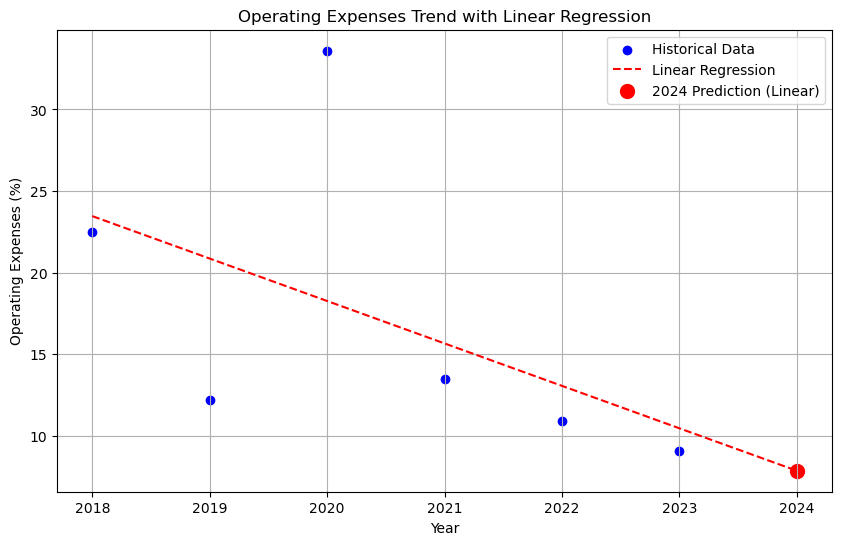

In [31]:
# Predicting for Operating Expenses
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Historical data
years = np.array([2018, 2019, 2020, 2021, 2022, 2023]).reshape(-1, 1)
expenses = np.array([22.5, 12.2, 33.6, 13.5, 10.9, 9.1])

# Fit simple linear regression
lin_reg = LinearRegression()
lin_reg.fit(years, expenses)

# Predict for 2024
year_2024 = np.array([[2024]])
predicted_expense = lin_reg.predict(year_2024)[0]
print(f"Predicted Operating Expense for 2024 (Linear Regression): {predicted_expense:.5f}%")

# Plot historical data + linear regression line
plt.figure(figsize=(10, 6))
plt.scatter(years, expenses, color='blue', label='Historical Data')

# Create smooth line over years + 2024
future_years = np.append(years, 2024).reshape(-1, 1)
lin_preds = lin_reg.predict(future_years)
plt.plot(future_years, lin_preds, color='red', linestyle='--', label='Linear Regression')

# Plot 2024 prediction as a point
plt.scatter(2024, predicted_expense, color='red', marker='o', s=100, label='2024 Prediction (Linear)')

plt.xlabel('Year')
plt.ylabel('Operating Expenses (%)')
plt.title('Operating Expenses Trend with Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Ivan Tan\AppData\Local\Temp\ipykernel_39504\2648356763.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df_sorted, x='AbsCorrelation', y='Category', palette='viridis')


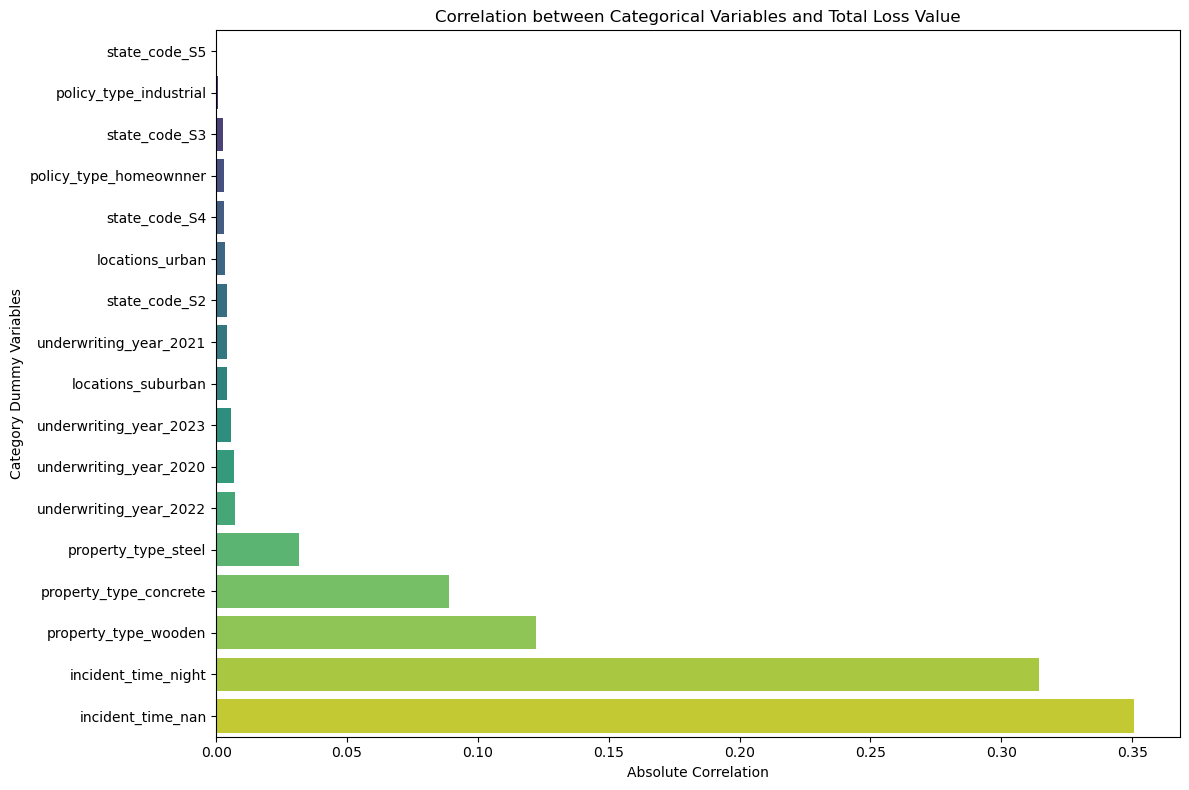

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and target is 'total_loss_value'
target = 'total_loss_value'


# Store correlations
correlations = {}

# Loop through categorical variables
for col in categorical_cols:
    # One-hot encode the column
    dummies = pd.get_dummies(data[col], prefix=col, drop_first=True)
    
    # Compute correlation for each dummy variable
    for dummy_col in dummies.columns:
        corr = np.corrcoef(dummies[dummy_col], data[target])[0, 1]
        correlations[dummy_col] = corr

# Convert to DataFrame
corr_df = pd.DataFrame(list(correlations.items()), columns=['Category', 'Correlation'])

# Drop NaNs and take absolute value (optional, for strength only)
corr_df = corr_df.dropna()
corr_df['AbsCorrelation'] = corr_df['Correlation'].abs()

# Sort by descending order
corr_df_sorted = corr_df.sort_values(by='AbsCorrelation', ascending=True)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=corr_df_sorted, x='AbsCorrelation', y='Category', palette='viridis')
plt.title('Correlation between Categorical Variables and Total Loss Value')
plt.xlabel('Absolute Correlation')
plt.ylabel('Category Dummy Variables')
plt.tight_layout()
plt.show()

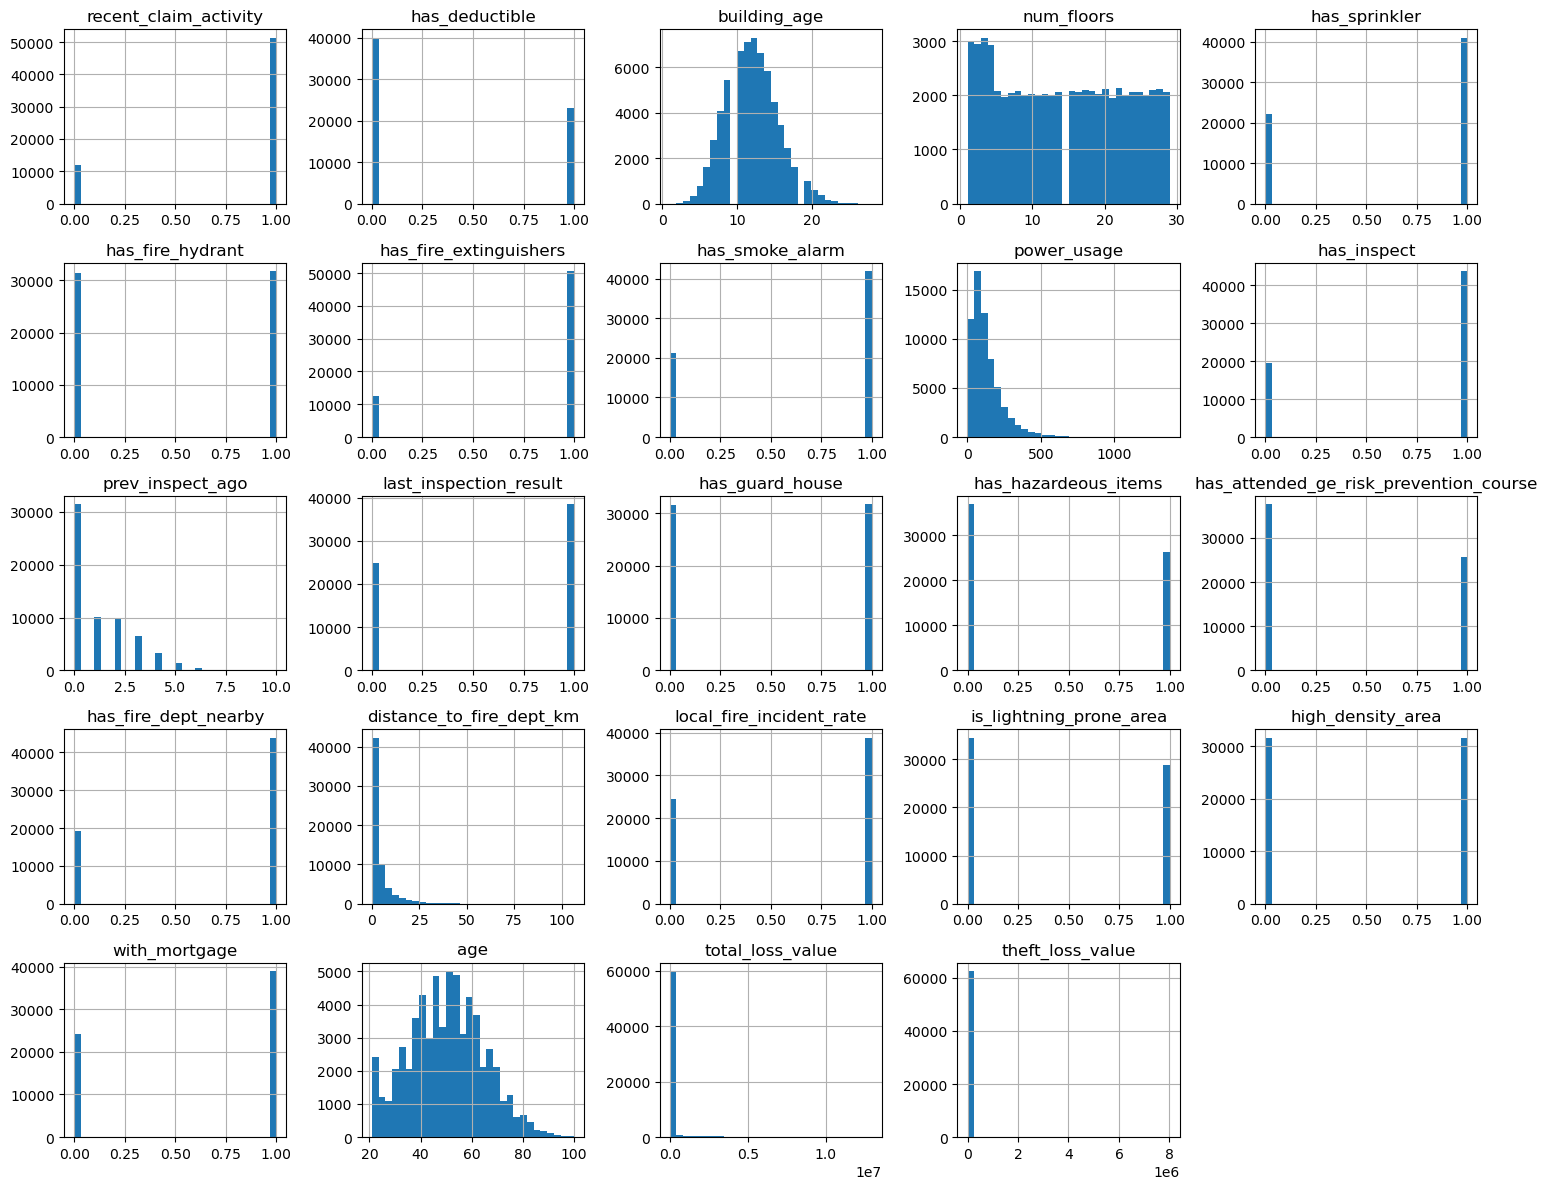

In [47]:
# Plot histograms
data[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

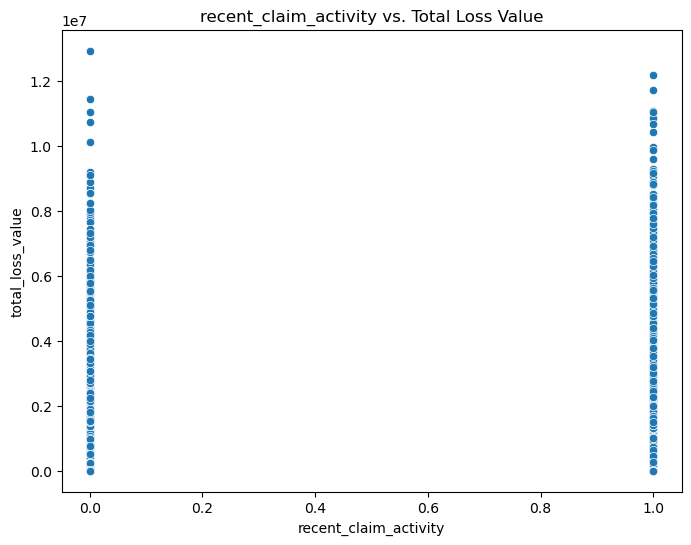

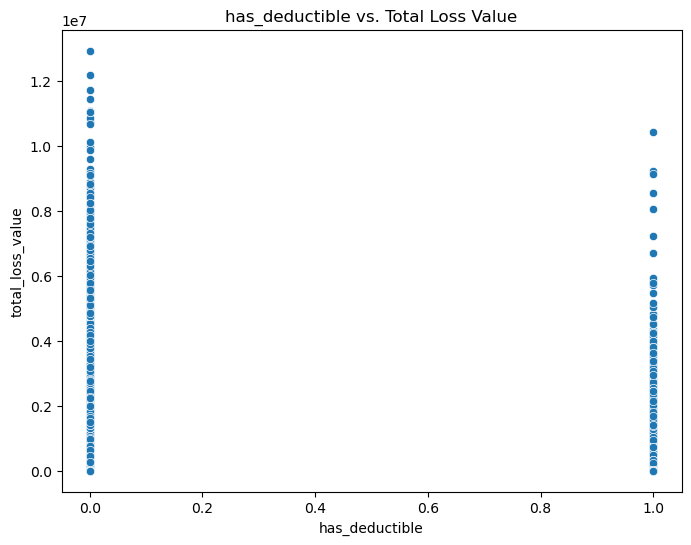

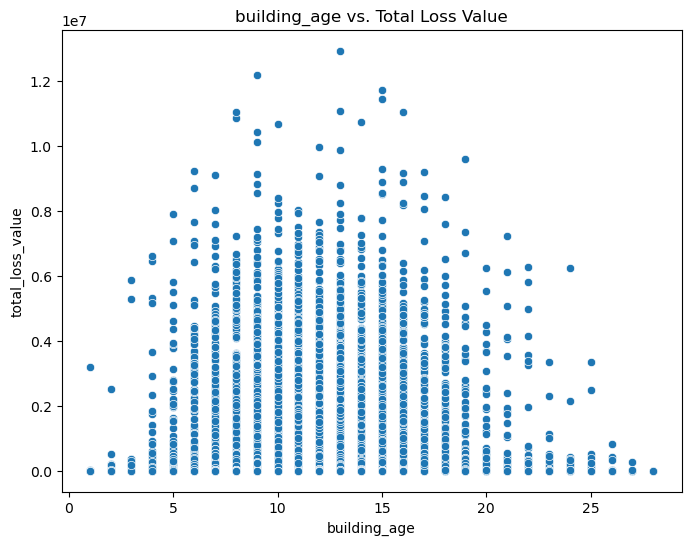

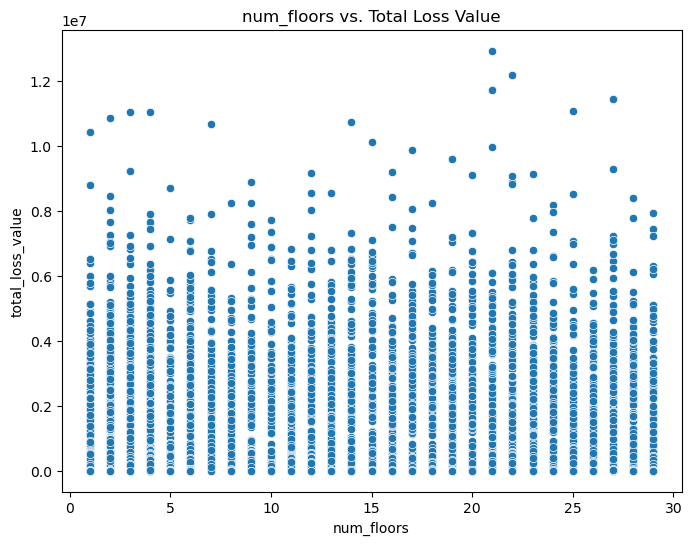

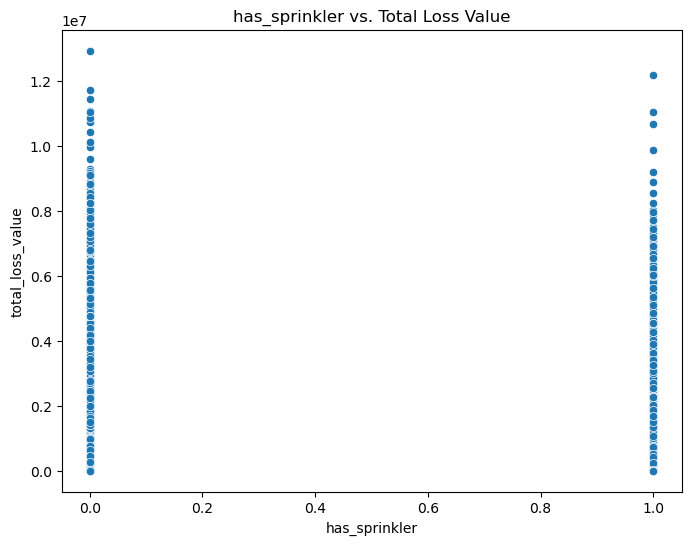

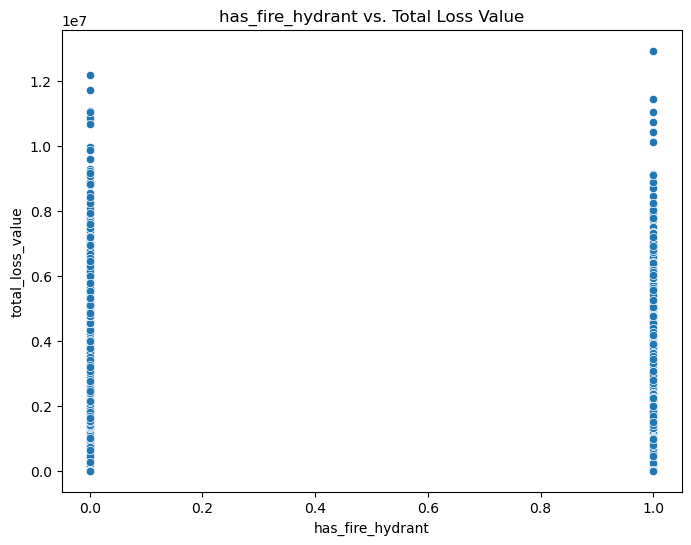

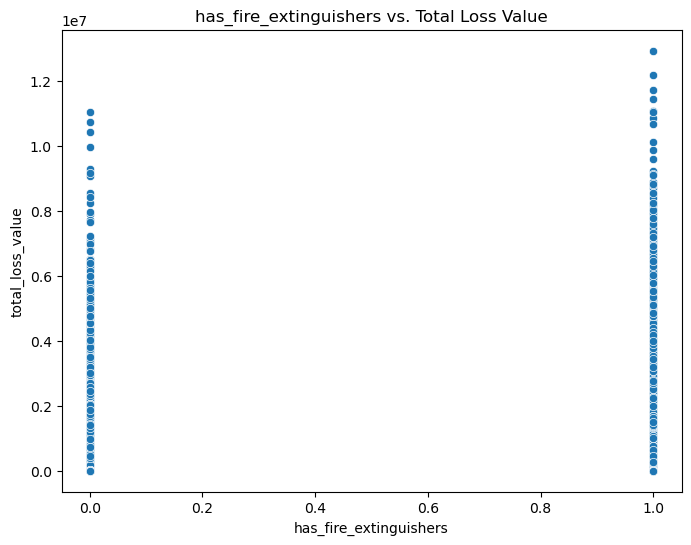

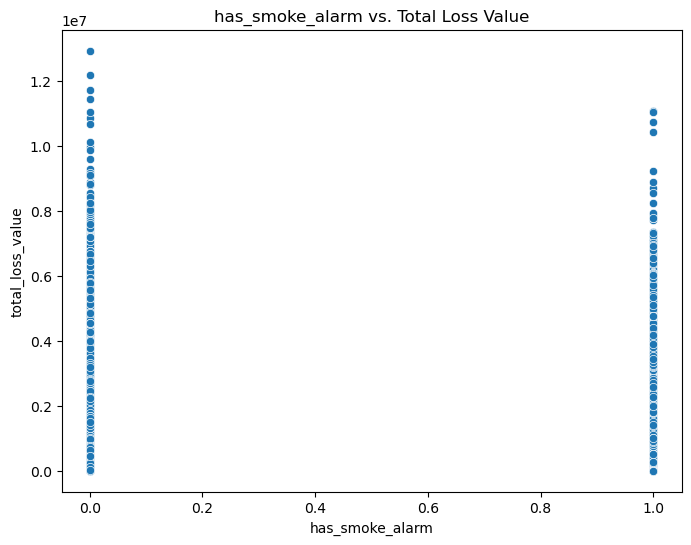

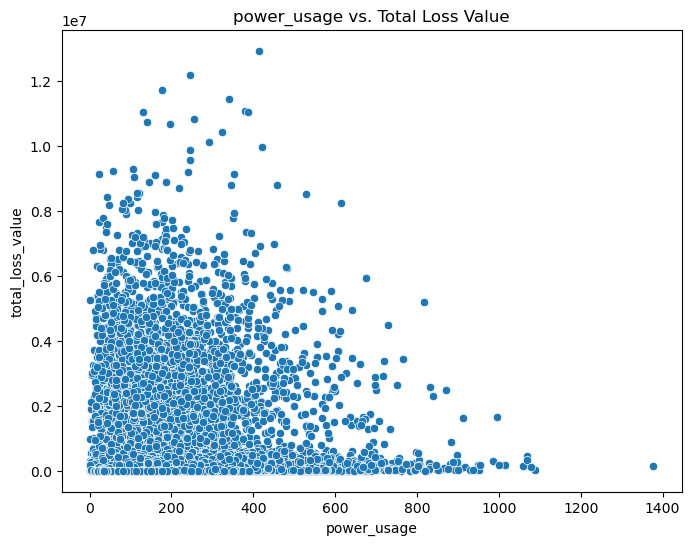

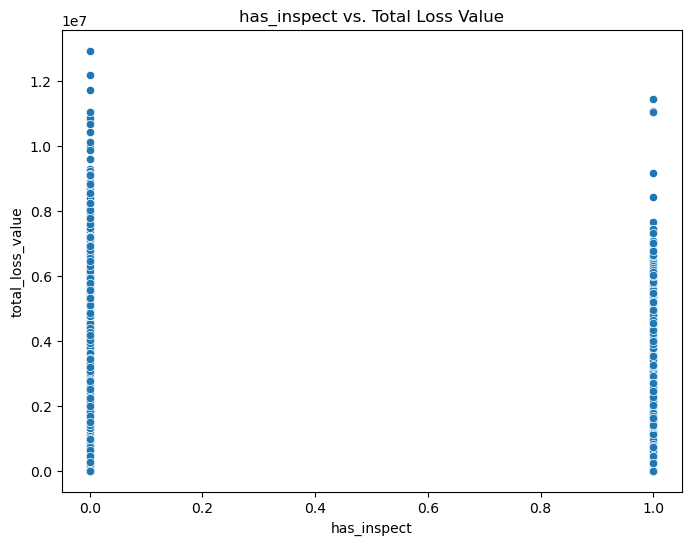

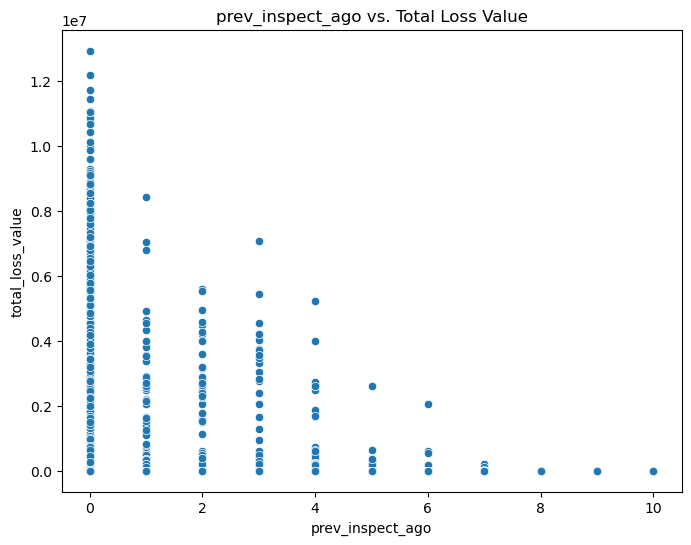

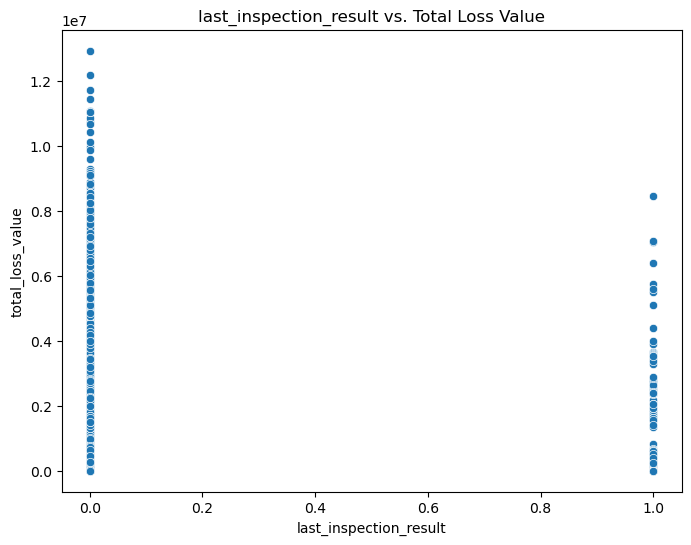

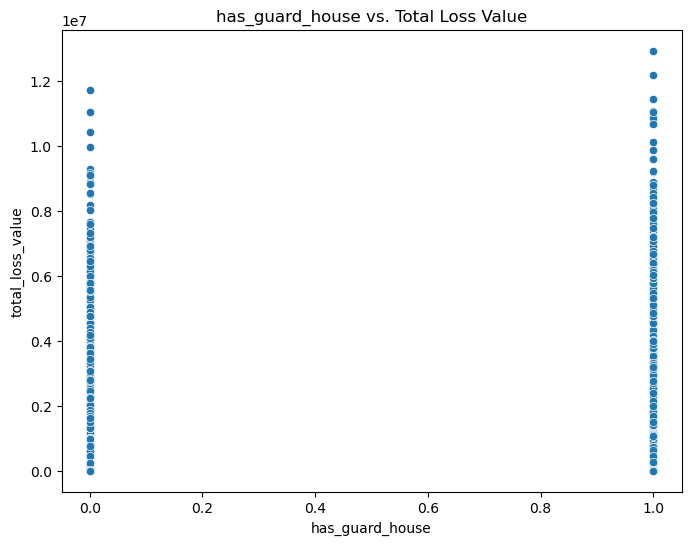

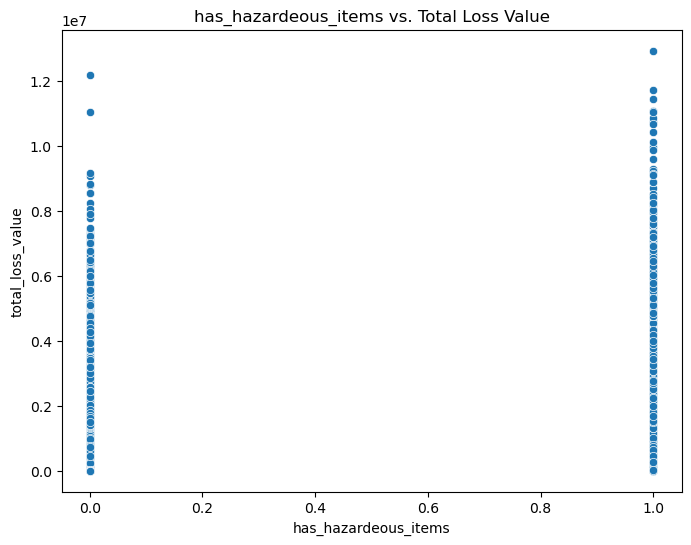

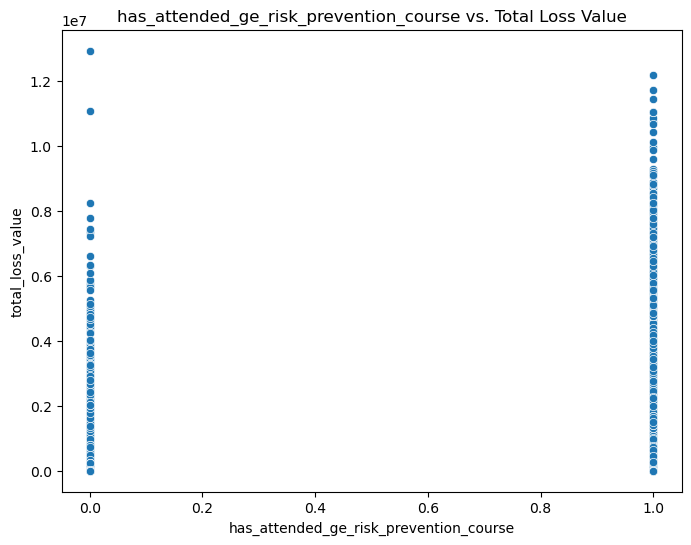

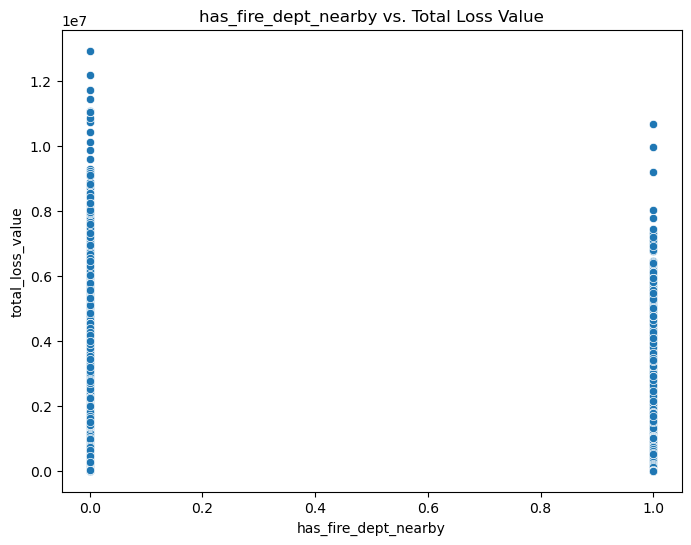

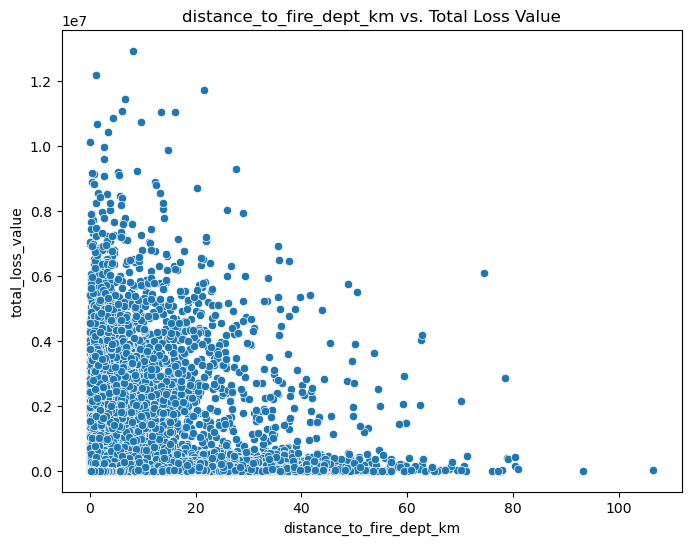

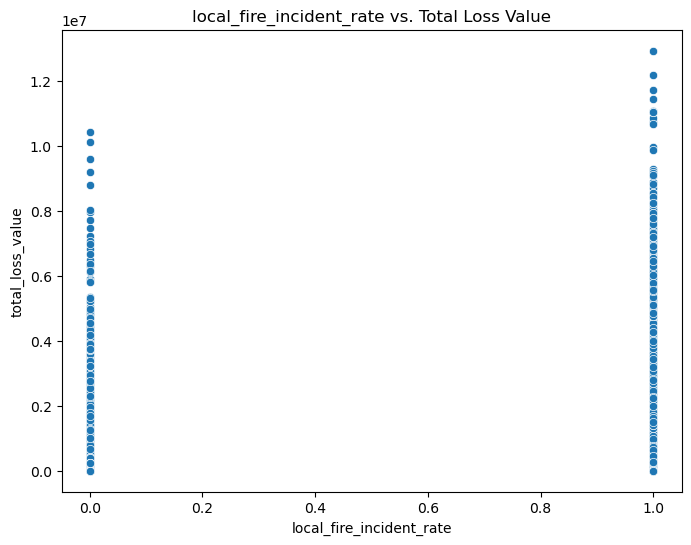

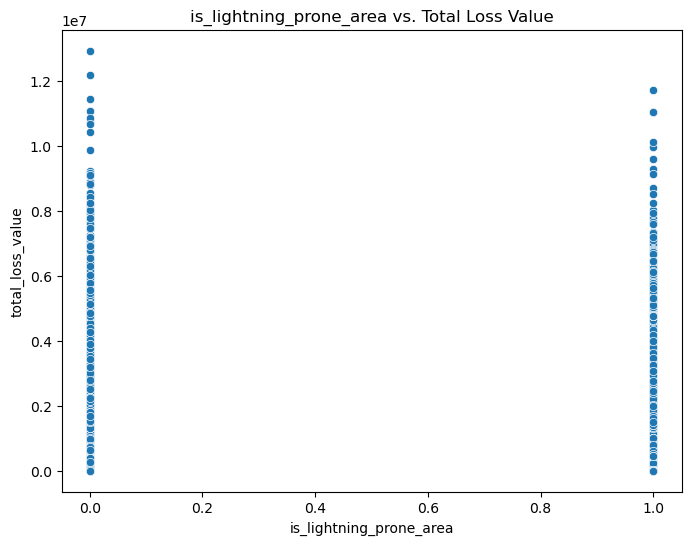

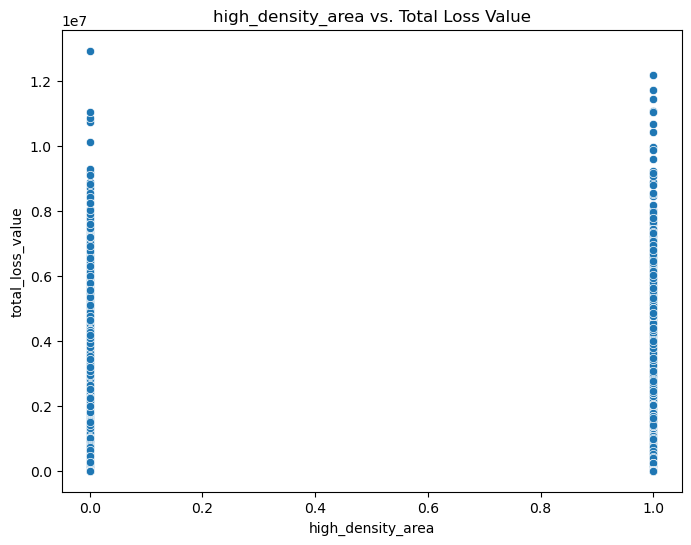

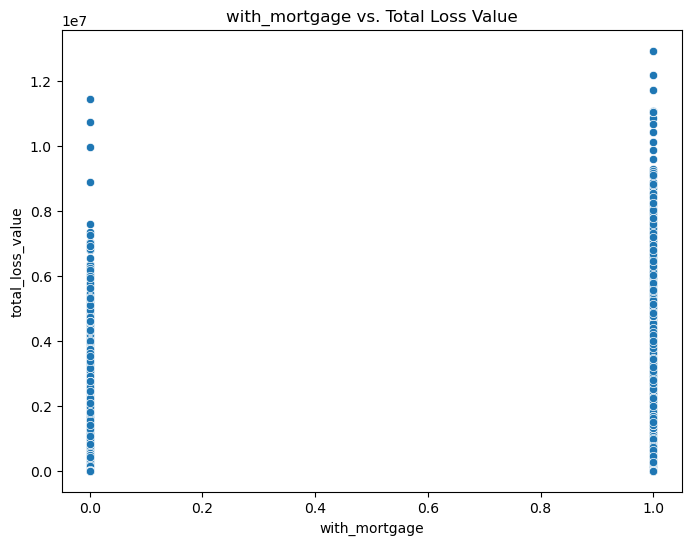

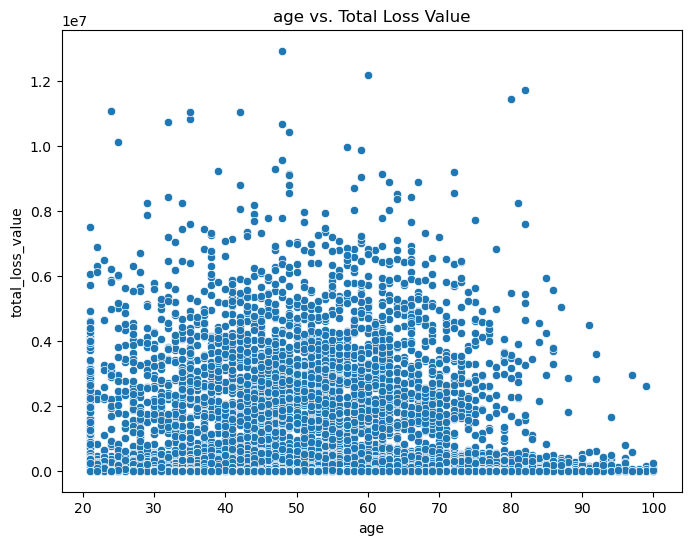

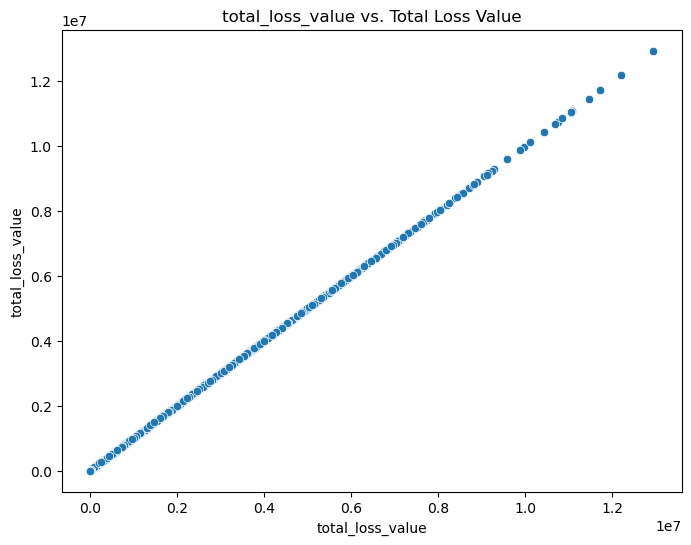

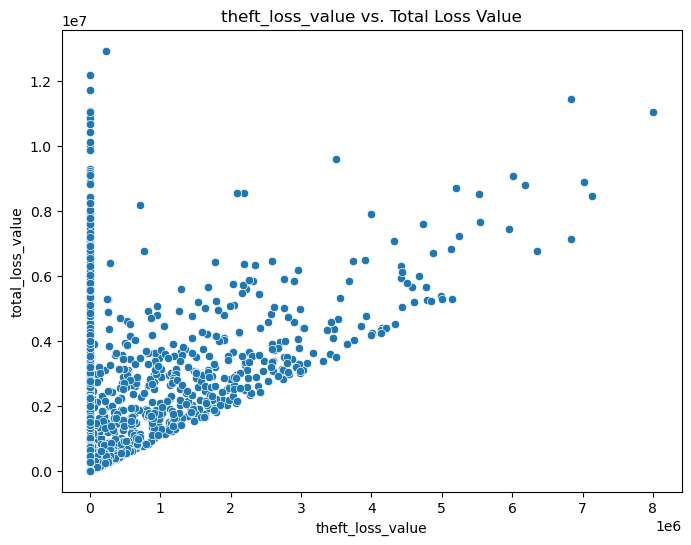

In [52]:
# Scatterplots for numeric variables
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col, y='total_loss_value', data=data)
    plt.title(f'{col} vs. Total Loss Value')
    plt.show()

In [ ]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Loop through each categorical variable and plot boxplots
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='total_loss_value', data=df)
    plt.title(f'Boxplot of Total Loss Value by {col}')
    plt.xlabel(col)
    plt.ylabel('Total Loss Value')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [27]:
# Final Dataset
predict_data = pd.read_csv('property_insurance_final_data.csv')